# Exp 4a - Stability (Perturbation Analysis)

**Question**:

Exp 2 showed that cross-domain graph fusion ($\alpha=0.5$) yields the best recommendation performance. Exp 3 established that ChebNet ($K=3$) is the optimal GNN architecture. But does greater model flexibility lead to increased sensitivity to noise? If we introduce realistic noise—such as missing edges or noisy features—do these GNN architectures degrade gracefully?


**Headline**:

All evaluated GNN architectures exhibit "graceful degradation" under various graph perturbations. However, a clear trade-off between peak accuracy and robustness emerges:

- **ChebNet (K = 3)**: Achieves the best baseline performance but is moderately sensitive to structural perturbations (with up to 7.6% NDCG@20 drop under edge dropout). Its performance remains relatively stable under feature noise.

- **GraphSAGE**: The most robust architecture, showing minimal degradation across perturbations. It remains highly stable under both weight and feature noise, with only a small ~2.1% drop under edge dropout.

- **GCN**: The least stable model overall, suffering the largest performance drops across all perturbation types (e.g., ~9.0% under edge dropout and ~7.1% under weight noise).

**Key Insight**:
* Structural perturbations have the largest impact on recommendation quality.
* The relative destructiveness follows a clear pattern:
Structural noise > Weight noise ≈ Feature noise

**Perturbation Methodology**:

To rigorously evaluate the robustness of our GNN architectures against real-world noise, we apply three distinct families of perturbations to the optimal fused graph ($\alpha=0.5$). Each perturbation simulates a different type of data degradation:

* **Edge Dropout (Structural Noise)**
    * **Tested Levels (Keep Ratios):** 0.95, 0.90, 0.80, and 0.70 (i.e., dropping 5%, 10%, 20%, and 30% of edges).
    * **Simulated Scenario:** Randomly removes existing edges to simulate incomplete graph data. This models real-world situations like data sparsity, unrecorded implicit user feedback, or missing interaction logs, directly damaging the graph's topological structure.

* **Edge Weight Noise**
    * **Tested Levels ($\sigma$):** 0.05, 0.10, and 0.20.
    * **Simulated Scenario:** Injects Gaussian noise ($N(0, \sigma^2)$) into the existing edge weights without altering the graph's connectivity. This simulates computational errors or evaluation biases when calculating the similarity or affinity between nodes (e.g., users).

* **Node Feature Noise**
    * **Tested Levels ($\sigma$):** 0.05, 0.10, and 0.20.
    * **Simulated Scenario:** Adds Gaussian noise directly to the user feature profiles (the input feature matrix). This simulates "user profile pollution" or defects in upstream feature engineering, where the collected foundational information might be misleading or preprocessing introduces noise.

**Experimental Rigor:**
For each specific perturbation type and intensity level, the models are retrained and evaluated across **3 distinct random seeds (42, 43, 44)**. This approach ensures that our resulting performance degradation curves are statistically robust and not merely the result of a single anomalous random initialization.

## 1. Setup and Imports
This cell imports the necessary libraries for data processing and professional-grade plotting.

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("/content/drive/MyDrive/large_scale_graph_final_project/Experiment2")
OUT_DIR = PROJECT_ROOT / "results" / "stability"
RESULTS_CSV = OUT_DIR / "stability_results.csv"

print(f"Prepare to read the result file: {RESULTS_CSV}")

Prepare to read the result file: /content/drive/MyDrive/large_scale_graph_final_project/Experiment2/results/stability/stability_results.csv


## 2. Data Loading and Metrics Identification
This cell loads the CSV generated by our experiment loop and identifies the specific NDCG@20 column for analysis.

In [39]:
if not RESULTS_CSV.exists():
    raise FileNotFoundError(f"Ensure that {RESULTS_CSV} has been generated by your experiment script.")

df = pd.read_csv(RESULTS_CSV)

ndcg_cols = [c for c in df.columns if "test_" in c and "NDCG@20" in c]
if not ndcg_cols:
    ndcg_cols = [c for c in df.columns if "val_" in c and "NDCG@20" in c]

target_metric = ndcg_cols[0]
print(f"Analyzing metric: {target_metric}")

display(df.head())

Analyzing metric: test_NDCG@20


,model,graph,alpha_mode,alpha_value,device,best_epoch,epochs_ran,train_time_total_seconds,use_enriched_features,highrated_sampling,...,test_Recall@20,test_NDCG@10,test_NDCG@20,test_HitRate@20,run_name,display_name,model_kind,perturb_type,perturb_strength,seed
0,ChebNet fused a=0.5,fused,fixed,0.5,cuda,49,69,55.247271,False,False,...,0.004139,0.001585,0.002183,0.015577,chebnet_fused_a05,ChebNet fused a=0.5,chebnet,edge_dropout,0.05,42
1,ChebNet fused a=0.5,fused,fixed,0.5,cuda,43,63,49.534318,False,False,...,0.004196,0.001539,0.002169,0.015503,chebnet_fused_a05,ChebNet fused a=0.5,chebnet,edge_dropout,0.05,43
2,ChebNet fused a=0.5,fused,fixed,0.5,cuda,52,72,55.643331,False,False,...,0.003916,0.001625,0.002162,0.015577,chebnet_fused_a05,ChebNet fused a=0.5,chebnet,edge_dropout,0.05,44
3,ChebNet fused a=0.5,fused,fixed,0.5,cuda,45,65,50.140483,False,False,...,0.003684,0.001519,0.002005,0.014242,chebnet_fused_a05,ChebNet fused a=0.5,chebnet,edge_dropout,0.10,42
4,ChebNet fused a=0.5,fused,fixed,0.5,cuda,43,63,49.425828,False,False,...,0.004160,0.001516,0.002195,0.015132,chebnet_fused_a05,ChebNet fused a=0.5,chebnet,edge_dropout,0.10,43


## 3. Statistical Aggregation
We group the data by model and perturbation level to calculate the mean and standard deviation across three random seeds (42, 43, 44).

In [40]:
summary_df = df.groupby(
    ["display_name", "perturb_type", "perturb_strength"],
    as_index=False
).agg(
    mean_ndcg=(target_metric, "mean"),
    std_ndcg=(target_metric, "std"),
    count=(target_metric, "count")
).sort_values(["perturb_type", "perturb_strength"])

summary_df.to_csv(OUT_DIR / "stability_summary.csv", index=False)
print("Summary statistics calculated and saved.")

Summary statistics calculated and saved.


## 4. Comparative Robustness Analysis
This cell generates separate plots for each perturbation type (Edge Dropout, Edge Weight Noise, and Node Feature Noise) to compare model performance degradation.

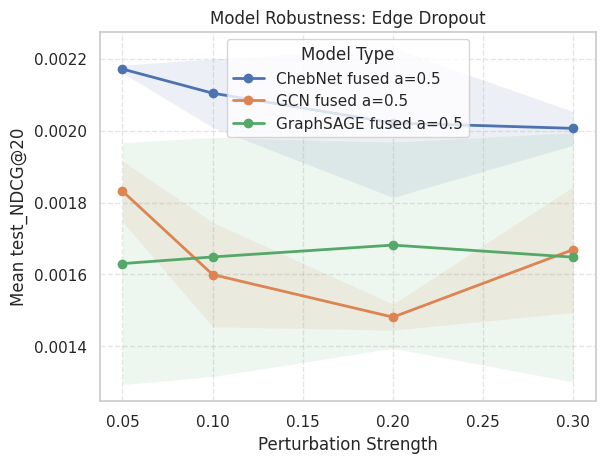

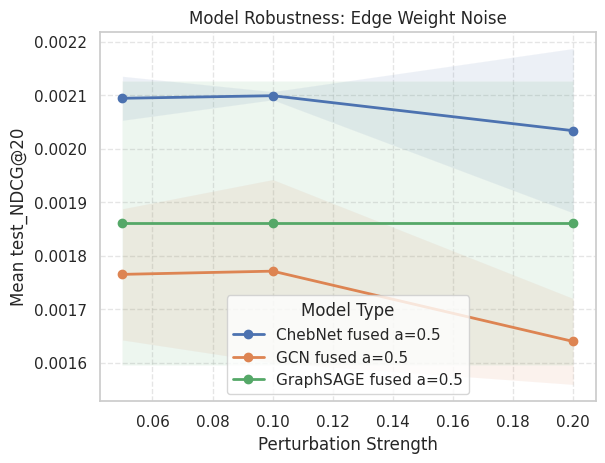

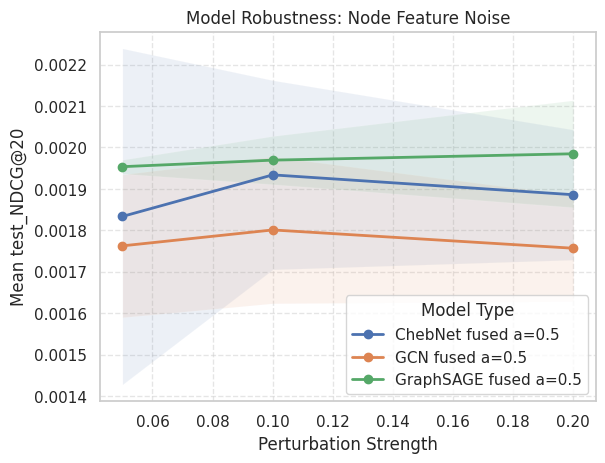

In [36]:
perturbations = summary_df["perturb_type"].unique()

for p_type in perturbations:
    plt.figure()
    subset = summary_df[summary_df["perturb_type"] == p_type]

    for model in subset["display_name"].unique():
        model_data = subset[subset["display_name"] == model].sort_values("perturb_strength")

        x = model_data["perturb_strength"]
        y = model_data["mean_ndcg"]
        error = model_data["std_ndcg"].fillna(0) # Standard deviation across seeds [cite: 331]

        plt.plot(x, y, marker='o', label=model, linewidth=2)
        plt.fill_between(x, y - error, y + error, alpha=0.1)

    plt.title(f"Model Robustness: {p_type.replace('_', ' ').title()}")
    plt.xlabel("Perturbation Strength")
    plt.ylabel(f"Mean {target_metric}")
    plt.legend(title="Model Type")
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.show()

## 5. Single Model Sensitivity Analysis
Focus on the primary model (e.g., ChebNet fused a=0.5) to see which type of noise impacts its performance the most.

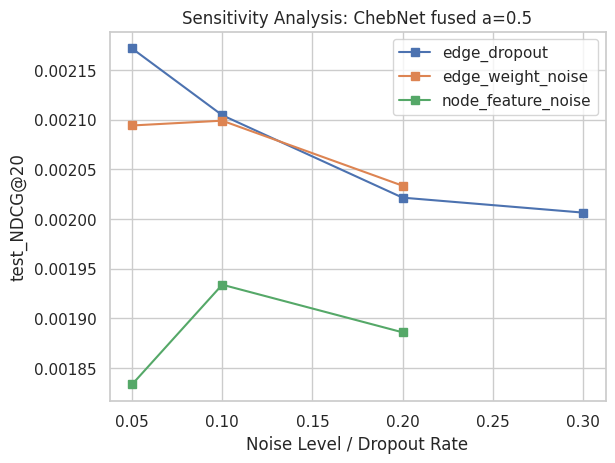

In [37]:
primary_model = summary_df["display_name"].unique()[0]
model_sensitivity = summary_df[summary_df["display_name"] == primary_model]

plt.figure()
for p_type in model_sensitivity["perturb_type"].unique():
    data = model_sensitivity[model_sensitivity["perturb_type"] == p_type].sort_values("perturb_strength")
    plt.plot(data["perturb_strength"], data["mean_ndcg"], marker='s', label=p_type)

plt.title(f"Sensitivity Analysis: {primary_model}")
plt.xlabel("Noise Level / Dropout Rate")
plt.ylabel(target_metric)
plt.legend()
plt.show()